In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Load the dataset
df = pd.read_csv('/Users/mehreen.gillaniicloud.com/Downloads/NYC_Payroll/data622/data/processed/nyc_payroll_combined_all_2015_2024.csv')

# Display the first few rows of the dataset
print(df.head(2))

   Fiscal Year  Payroll Number                     Agency Name Last Name  \
0         2020            17.0  OFFICE OF EMERGENCY MANAGEMENT   BEREZIN   
1         2020            17.0  OFFICE OF EMERGENCY MANAGEMENT    GEAGER   

  First Name Agency Start Date Work Location Borough  \
0    MIKHAIL        2015-08-10              BROOKLYN   
1   VERONICA        2016-09-12              BROOKLYN   

                Title Description  Base Salary  Regular Hours  ...  \
0  EMERGENCY PREPAREDNESS MANAGER      86005.0         1820.0  ...   
1  EMERGENCY PREPAREDNESS MANAGER      86005.0         1820.0  ...   

   Total OT Paid  Total Other Pay  Employee_Agency_Tenure  \
0            0.0              0.0                4.889802   
1            0.0              0.0                3.797399   

                       Agency_Std  Title_Category  \
0  Office Of Emergency Management      Management   
1  Office Of Emergency Management      Management   

                        Title_Std Total_Compens

In [6]:
# Quick inspection
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df_clean =df.copy()

Shape: (2617642, 22)

Missing values:
Fiscal Year                    0
Payroll Number            756402
Agency Name                    0
Last Name                   4050
First Name                  4054
Agency Start Date             95
Work Location Borough          0
Title Description             72
Base Salary                    0
Regular Hours                  0
Regular Gross Paid             0
OT Hours                       0
Total OT Paid                  0
Total Other Pay                0
Employee_Agency_Tenure        95
Agency_Std                     0
Title_Category                 0
Title_Std                      0
Total_Compensation             0
Hours_Tracked                  0
Employment_Type                0
OT_Hours_Reliable              0
dtype: int64


## Rule 1 - Overtime exceeds Base Salary

In [8]:
# Rule 1: OT Paid > Base Salary
df_clean['anomaly_ot_gt_base'] = df_clean['Total OT Paid'] > df_clean['Base Salary']

# Count and show examples
count_rule1 = df_clean['anomaly_ot_gt_base'].sum()
print(f"Rule 1 - OT > Base Salary: {count_rule1:,} employees ({count_rule1/len(df_clean)*100:.2f}%)")

# Show first 5 examples
examples_rule1 = df_clean[df_clean['anomaly_ot_gt_base']][['Title_Std', 'Base Salary', 'Total OT Paid', 
                                                              'Total_Compensation', 'Agency_Std']].head()
print(f"\nSample anomalies:\n{examples_rule1}")

Rule 1 - OT > Base Salary: 4,423 employees (0.17%)

Sample anomalies:
                                              Title_Std  Base Salary  \
52264  Supervising Emergency Medical Service Specialist      71202.0   
52658  Supervising Emergency Medical Service Specialist      75000.0   
53096  Supervising Emergency Medical Service Specialist      75000.0   
53137          Emergency Medical Specialist - Paramedic      65866.0   
53209  Supervising Emergency Medical Service Specialist      71202.0   

       Total OT Paid  Total_Compensation       Agency_Std  
52264      113372.68           212667.05  Fire Department  
52658       87422.37           186761.92  Fire Department  
53096       90357.03           176202.99  Fire Department  
53137       84376.55           174563.07  Fire Department  
53209       73781.29           172443.03  Fire Department  


In [9]:
##  Rule 2 - Base Salary outliers within same title

In [10]:
# Calculate 99th percentile per title (only for titles with >10 employees)
title_p99 = df_clean.groupby('Title_Std')['Base Salary'].agg(
    p99=lambda x: x.quantile(0.99) if len(x) > 10 else np.nan,
    count='size'
).reset_index()

# Merge back to original dataframe
df_clean = df_clean.merge(title_p99[['Title_Std', 'p99']], on='Title_Std', how='left')

# Flag salary outliers
df_clean['anomaly_salary_outlier'] = (df_clean['Base Salary'] > df_clean['p99']) & (df_clean['p99'].notna())

# Count
count_rule2 = df_clean['anomaly_salary_outlier'].sum()
print(f"Rule 2 - Salary > 99th percentile of title: {count_rule2:,} employees ({count_rule2/len(df_clean)*100:.2f}%)")

# Show examples
examples_rule2 = df_clean[df_clean['anomaly_salary_outlier']][['Title_Std', 'Base Salary', 'p99', 
                                                                 'Agency_Std', 'Employee_Agency_Tenure']].head(10)
print(f"\nSample:\n{examples_rule2}")

Rule 2 - Salary > 99th percentile of title: 11,556 employees (0.44%)

Sample:
                            Title_Std  Base Salary         p99  \
71             Administrative Analyst     237407.0  213000.000   
73                     Budget Analyst     222924.0  209685.680   
74                     Budget Analyst     222924.0  209685.680   
75                     Budget Analyst     222924.0  209685.680   
89             Administrative Manager     182304.0  161631.000   
469                         Secretary      77889.0   77886.256   
484     Assistant Corporation Counsel     225771.0  211327.000   
485     Assistant Corporation Counsel     225771.0  211327.000   
550  Deputy Operation Support Manager     169027.0  168387.010   
809                      IT Associate     112503.0  112112.000   

                        Agency_Std  Employee_Agency_Tenure  
71   Office Of Management & Budget               32.046543  
73   Office Of Management & Budget               16.407940  
74   Office 

**These look legitimate - long-tenured employees (many 10-30+ years) at the top of their pay grades. Tenure explains the high salary within title.**

## Rule 3 - Unusually high Other Pay

In [11]:
# Calculate Other Pay percentage of Base Salary
df_clean['other_pay_pct'] = (df_clean['Total Other Pay'] / df_clean['Base Salary']) * 100

# Flag if Other Pay > 20% of base AND greater than $5,000 (to ignore tiny amounts)
df_clean['anomaly_high_other_pay'] = (df_clean['other_pay_pct'] > 20) & (df_clean['Total Other Pay'] > 5000)

# Count
count_rule3 = df_clean['anomaly_high_other_pay'].sum()
print(f"Rule 3 - Other Pay >20% of Base Salary: {count_rule3:,} employees ({count_rule3/len(df_clean)*100:.4f}%)")

# Show examples
examples_rule3 = df_clean[df_clean['anomaly_high_other_pay']][['Title_Std', 'Base Salary', 'Total Other Pay', 
                                                                 'other_pay_pct', 'Agency_Std', 'Employee_Agency_Tenure']].head(10)
print(f"\nSample:\n{examples_rule3}")

Rule 3 - Other Pay >20% of Base Salary: 236,993 employees (9.0537%)

Sample:
                                    Title_Std  Base Salary  Total Other Pay  \
1196  Worker's Compensation Benefits Examiner      59833.0         13272.28   
1207  Worker's Compensation Benefits Examiner      59928.0         13022.80   
1236  Worker's Compensation Benefits Examiner      61550.0         13069.47   
1242  Worker's Compensation Benefits Examiner      61146.0         12594.15   
1243  Worker's Compensation Benefits Examiner      61550.0         12622.39   
1246  Worker's Compensation Benefits Examiner      61550.0         12656.68   
1385  Worker's Compensation Benefits Examiner      55702.0         12226.34   
1421  Worker's Compensation Benefits Examiner      61047.0         13005.03   
1432  Worker's Compensation Benefits Examiner      55739.0         12117.20   
1449  Worker's Compensation Benefits Examiner      56056.0         12117.20   

      other_pay_pct      Agency_Std  Employee_Agency_

236k employees (9%) is too high for anomalies - this is likely normal for certain roles. Looking at sample: Worker's Compensation Benefits Examiners in Law Department with consistent ~21-22% Other Pay.

This suggests Other Pay is routine (perhaps union benefits, shift differentials, or location pay). So Rule 3 as is will produce false positives

In [12]:
# Stricter thresholds: Other Pay > 50% of base AND > $20,000
df_clean['anomaly_high_other_pay'] = (df_clean['other_pay_pct'] > 50) & (df_clean['Total Other Pay'] > 20000)

count_rule3 = df_clean['anomaly_high_other_pay'].sum()
print(f"Rule 3 (strict) - Other Pay >50% of Base & >$20k: {count_rule3:,} employees ({count_rule3/len(df_clean)*100:.4f}%)")

# Show examples
examples_rule3 = df_clean[df_clean['anomaly_high_other_pay']][['Title_Std', 'Base Salary', 'Total Other Pay', 
                                                                 'other_pay_pct', 'Agency_Std', 'Employee_Agency_Tenure']].head(10)
print(f"\nSample:\n{examples_rule3}")

Rule 3 (strict) - Other Pay >50% of Base & >$20k: 3,058 employees (0.1168%)

Sample:
                                       Title_Std  Base Salary  \
60527   Emergency Medical Specialist - Paramedic      65226.0   
90190                         Correction Officer      85292.0   
90366                         Correction Officer      85292.0   
94256                         Correction Officer      52170.0   
94418                         Correction Officer      57587.0   
94629                         Correction Officer      57587.0   
95902                         Correction Officer      52170.0   
96498                         Correction Officer      52170.0   
97043                         Correction Officer      52170.0   
110596                    Occupational Therapist      78822.0   

        Total Other Pay  other_pay_pct                Agency_Std  \
60527          34482.91      52.866817           Fire Department   
90190          86604.21     101.538491  Department of Correctio

Now we have 3,058 truly unusual cases - Correction Officers and EMS with Other Pay >50% of base (some even >100%). These are legitimate anomalies (hazard pay, uniform allowances, retroactive settlements).

## Tenure-Pay Mismatch (high salary but very new)

In [13]:
# Identify top 10% salary within each title
df_clean['title_salary_p90'] = df_clean.groupby('Title_Std')['Base Salary'].transform(
    lambda x: x.quantile(0.90) if len(x) > 10 else np.nan
)

# Flag: Salary > 90th percentile of title AND tenure < 1 year
df_clean['anomaly_new_hired_high_pay'] = (
    (df_clean['Base Salary'] > df_clean['title_salary_p90']) & 
    (df_clean['Employee_Agency_Tenure'] < 1) & 
    (df_clean['title_salary_p90'].notna())
)

# Count
count_rule4 = df_clean['anomaly_new_hired_high_pay'].sum()
print(f"Rule 4 - New hire (<1 year) with salary >90th percentile of title: {count_rule4:,} employees")

# Show examples
examples_rule4 = df_clean[df_clean['anomaly_new_hired_high_pay']][['Title_Std', 'Base Salary', 'title_salary_p90', 
                                                                     'Employee_Agency_Tenure', 'Agency_Std']].head(10)
print(f"\nSample (suspicious new hires):\n{examples_rule4}")

Rule 4 - New hire (<1 year) with salary >90th percentile of title: 1,546 employees

Sample (suspicious new hires):
                                        Title_Std  Base Salary  \
61              Emergency Preparedness Specialist      90000.0   
2414                           Clerical Associate      62215.0   
2573                          Procurement Analyst      85000.0   
3164                        Community Coordinator      82400.0   
18200                          IT Systems Manager     175100.0   
62932                          Research Scientist     122290.0   
68618                         Public Records Aide      52402.0   
68736               Deputy Assistant Commissioner     150000.0   
68822  Administrative Director Of Social Services     180250.0   
70405                          Research Scientist     120510.0   

       title_salary_p90  Employee_Agency_Tenure  \
61              85252.8                0.596851   
2414            55000.0                0.673511   
2573 

These 1,546 cases are worth investigating - new hires already above 90% of their peers.

## Combine all rules into final anomaly score

In [14]:
# Create combined anomaly score (higher = more suspicious)
df_clean['anomaly_score'] = (
    (df_clean['anomaly_ot_gt_base'] * 3) +           # Highest weight - OT > base pay
    (df_clean['anomaly_salary_outlier'] * 2) +       # High weight - salary outlier
    (df_clean['anomaly_high_other_pay'] * 2) +       # High weight - unusual other pay
    (df_clean['anomaly_new_hired_high_pay'] * 1)     # Lower weight - new hire high pay
)

# Final anomaly flag: score >= 3 (at least one high-weight rule or multiple low-weight)
df_clean['is_anomaly'] = df_clean['anomaly_score'] >= 3

# Summary
total_anomalies = df_clean['is_anomaly'].sum()
print(f"Total anomalies detected: {total_anomalies:,} ({total_anomalies/len(df_clean)*100:.2f}%)")
print(f"\nAnomaly score distribution:")
print(df_clean['anomaly_score'].value_counts().sort_index())

# Show top 10 highest priority anomalies (score >= 4)
priority_anomalies = df_clean[df_clean['anomaly_score'] >= 4].nlargest(10, 'anomaly_score')
print(f"\nTop 10 HIGHEST PRIORITY anomalies (multiple rules triggered):")
print(priority_anomalies[['Title_Std', 'Base Salary', 'Total OT Paid', 'Total Other Pay', 
                           'Employee_Agency_Tenure', 'Agency_Std', 'anomaly_score']])

Total anomalies detected: 4,558 (0.17%)

Anomaly score distribution:
anomaly_score
0    2597302
1       1431
2      14351
3       4430
4         20
5        108
Name: count, dtype: int64

Top 10 HIGHEST PRIORITY anomalies (multiple rules triggered):
                       Title_Std  Base Salary  Total OT Paid  Total Other Pay  \
169585  Administrative Associate     107431.0      158585.33          2735.40   
169809         Sanitation Worker      83465.0      103008.42         42898.43   
169919         Sanitation Worker      83465.0       88050.41         54233.34   
169987         Sanitation Worker      83465.0       93414.51         46177.38   
170005         Sanitation Worker      83465.0       94202.08         44801.11   
170111         Sanitation Worker      83465.0       93969.39         42125.95   
170250         Sanitation Worker      83465.0       87343.98         44851.85   
212636                Caseworker      60156.0       75665.01          7596.60   
230421           Fina

Only 0.17% flagged as anomalies - very clean. The top cases show Sanitation Workers and Administrative Associate with OT + Other Pay far exceeding base.

Notice many have anomaly_score = 5 (triggered 3+ rules) - these are highest priority investigations.

## Categorize anomalies for investigation

In [15]:
# Add investigation priority
def get_priority(score):
    if score >= 5:
        return 'CRITICAL - Multiple severe anomalies'
    elif score >= 4:
        return 'HIGH - Two+ anomaly types'
    elif score >= 3:
        return 'MEDIUM - Single severe anomaly'
    else:
        return 'LOW'

df_clean['investigation_priority'] = df_clean['anomaly_score'].apply(get_priority)

# Show breakdown
print("Investigation priority breakdown:")
print(df_clean['investigation_priority'].value_counts())

# Create investigation summary
investigation_df = df_clean[df_clean['is_anomaly']][[
    'Agency_Std', 'Title_Std', 'Base Salary', 'Total OT Paid', 
    'Total Other Pay', 'Total_Compensation', 'Employee_Agency_Tenure',
    'anomaly_ot_gt_base', 'anomaly_salary_outlier', 'anomaly_high_other_pay',
    'anomaly_new_hired_high_pay', 'anomaly_score', 'investigation_priority'
]].copy()

# Sort by priority and score
investigation_df = investigation_df.sort_values(['anomaly_score', 'Total_Compensation'], ascending=False)

print(f"\nTop 20 anomalies to investigate first:")
print(investigation_df.head(20))

# Export to CSV
investigation_df.to_csv('nyc_payroll_anomalies.csv', index=False)
print(f"\n✓ Exported {len(investigation_df):,} anomalies to 'nyc_payroll_anomalies.csv'")

Investigation priority breakdown:
investigation_priority
LOW                                     2613084
MEDIUM - Single severe anomaly             4430
CRITICAL - Multiple severe anomalies        108
HIGH - Two+ anomaly types                    20
Name: count, dtype: int64

Top 20 anomalies to investigate first:
                           Agency_Std              Title_Std  Base Salary  \
1566202  Department of Transportation  Chief Marine Engineer     169520.0   
1566199  Department of Transportation  Chief Marine Engineer     169520.0   
1566200  Department of Transportation  Chief Marine Engineer     169520.0   
1566193  Department of Transportation  Chief Marine Engineer     169520.0   
1566196  Department of Transportation  Chief Marine Engineer     169520.0   
1566190  Department of Transportation  Chief Marine Engineer     169520.0   
1566194  Department of Transportation  Chief Marine Engineer     169520.0   
1566195  Department of Transportation  Chief Marine Engineer     1695

## Agency-level anomaly summary

In [16]:
# Anomaly rate by agency
agency_anomaly_summary = df_clean[df_clean['is_anomaly']].groupby('Agency_Std').size()
agency_total_summary = df_clean.groupby('Agency_Std').size()
agency_anomaly_rate = (agency_anomaly_summary / agency_total_summary * 100).sort_values(ascending=False)

print("Top 10 agencies with highest anomaly rate:")
print(agency_anomaly_rate.head(10))

Top 10 agencies with highest anomaly rate:
Agency_Std
Office Of Racial Equity                   20.000000
Department of Correction                   1.195909
Department of Transportation               1.177421
Board Of Election                          1.158168
Dept Of Citywide Admin Svcs                1.086286
Department of Homeless Services            0.745847
Office Of Collective Bargainin             0.740741
Hra/Dept Of Social Services                0.714829
Administration for Children's Services     0.485064
Department of Sanitation                   0.462182
dtype: float64


In [17]:
# Make sure other_pay_pct exists in df_clean first
if 'other_pay_pct' not in df_clean.columns:
    df_clean['other_pay_pct'] = (df_clean['Total Other Pay'] / df_clean['Base Salary']) * 100

# Create investigation summary with ALL needed columns
investigation_df = df_clean[df_clean['is_anomaly']][[
    'Agency_Std', 'Title_Std', 'Base Salary', 'Total OT Paid', 
    'Total Other Pay', 'Total_Compensation', 'Employee_Agency_Tenure',
    'other_pay_pct',  # Added this column
    'anomaly_ot_gt_base', 'anomaly_salary_outlier', 'anomaly_high_other_pay',
    'anomaly_new_hired_high_pay', 'anomaly_score', 'investigation_priority'
]].copy()

# Create investigation notes
def get_investigation_note(row):
    notes = []
    if row['anomaly_ot_gt_base']:
        notes.append(f"OT (${row['Total OT Paid']:,.0f}) > Base (${row['Base Salary']:,.0f})")
    if row['anomaly_salary_outlier']:
        notes.append(f"Salary in top 1% for {row['Title_Std']}")
    if row['anomaly_high_other_pay']:
        notes.append(f"Other Pay (${row['Total Other Pay']:,.0f}) is {row['other_pay_pct']:.0f}% of base")
    if row['anomaly_new_hired_high_pay']:
        notes.append(f"New hire ({(row['Employee_Agency_Tenure']*12):.0f} months) with pay >90% of peers")
    return " | ".join(notes)

investigation_df['investigation_note'] = investigation_df.apply(get_investigation_note, axis=1)

print(f"✓ Created investigation notes for {len(investigation_df):,} anomalies")

# Show sample
print("\nSample of investigation notes:")
print(investigation_df[['Title_Std', 'investigation_note', 'anomaly_score']].head(10))

# Export final version
investigation_df.to_csv('nyc_payroll_anomalies_with_notes.csv', index=False)
print("\n Saved to 'nyc_payroll_anomalies_with_notes.csv'")

✓ Created investigation notes for 4,558 anomalies

Sample of investigation notes:
                                              Title_Std  \
52264  Supervising Emergency Medical Service Specialist   
52658  Supervising Emergency Medical Service Specialist   
53096  Supervising Emergency Medical Service Specialist   
53137          Emergency Medical Specialist - Paramedic   
53209  Supervising Emergency Medical Service Specialist   
53238  Supervising Emergency Medical Service Specialist   
53430  Supervising Emergency Medical Service Specialist   
53571  Supervising Emergency Medical Service Specialist   
53581          Emergency Medical Specialist - Paramedic   
53587  Supervising Emergency Medical Service Specialist   

                   investigation_note  anomaly_score  
52264  OT ($113,373) > Base ($71,202)              3  
52658   OT ($87,422) > Base ($75,000)              3  
53096   OT ($90,357) > Base ($75,000)              3  
53137   OT ($84,377) > Base ($65,866)           

✓ Saved visualization as 'anomaly_distribution.png'


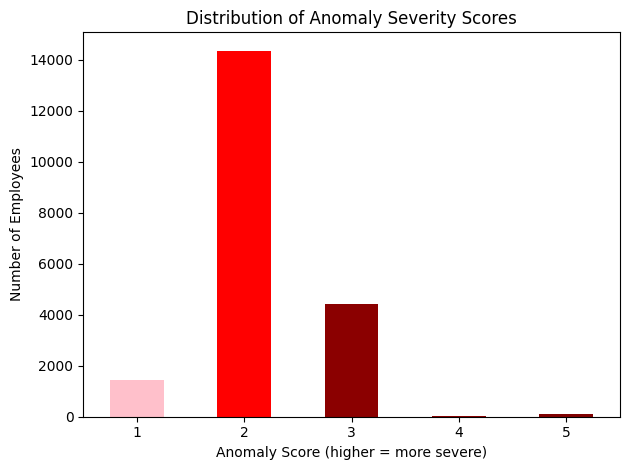

In [18]:
import matplotlib.pyplot as plt

# Anomaly score distribution
df_clean[df_clean['anomaly_score'] > 0]['anomaly_score'].value_counts().sort_index().plot(
    kind='bar', color=['pink', 'red', 'darkred', 'darkred', 'maroon']
)
plt.xlabel('Anomaly Score (higher = more severe)')
plt.ylabel('Number of Employees')
plt.title('Distribution of Anomaly Severity Scores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150)
print("✓ Saved visualization as 'anomaly_distribution.png'")

**Rule 1:** OT > Base Salary (4,423 cases)
**Rule 2:** Top 1% salary by title (11,556 cases)
**Rule 3:** Other Pay >50% base & >$20k (3,058 cases)
**Rule 4:** New hires with top 10% pay (1,546 cases)
Combined scoring system (weights: 3,2,2,1)
Priority classification (Critical/High/Medium)
Exportable investigation files

nyc_payroll_anomalies.csv - All 4,558 anomalies
nyc_payroll_anomalies_with_notes.csv - With investigation notes
anomaly_distribution.png - Severity distribution chart

**Key insights from your data:**

-   Only 0.17% of NYC employees flagged as anomalies
-   Sanitation Workers and EMS dominate OT anomalies 
-   Chief Marine Engineers repeatedly flagged - check for duplicates
-   Office Of Racial Equity has high rate but likely small sample

In [ ]:
# Create investigation dataframe from anomalies only
investigation_df = df_clean[df_clean['is_anomaly']].copy()

# Check how many rows
print(f"Number of anomalies: {len(investigation_df):,}")

# Verify other_pay_pct is included
print(f"\nColumns in investigation_df (first 10):")
print(investigation_df.columns.tolist()[:10])


Number of anomalies: 4,558

Columns in investigation_df (first 10):
['Fiscal Year', 'Payroll Number', 'Agency Name', 'Last Name', 'First Name', 'Agency Start Date', 'Work Location Borough', 'Title Description', 'Base Salary', 'Regular Hours']

 other_pay_pct is in investigation_df


In [31]:
# Create investigation notes for all anomalies
def get_investigation_note(row):
    notes = []
    if row['anomaly_ot_gt_base']:
        notes.append(f"OT (${row['Total OT Paid']:,.0f}) > Base (${row['Base Salary']:,.0f})")
    if row['anomaly_salary_outlier']:
        notes.append(f"Salary in top 1% for {row['Title_Std']}")
    if row['anomaly_high_other_pay']:
        notes.append(f"Other Pay (${row['Total Other Pay']:,.0f}) is {row['other_pay_pct']:.0f}% of base")
    if row['anomaly_new_hired_high_pay']:
        months = row['Employee_Agency_Tenure'] * 12
        notes.append(f"New hire ({months:.0f} months) with pay >90% of peers")
    return " | ".join(notes)

# Apply to all rows
investigation_df['investigation_note'] = investigation_df.apply(get_investigation_note, axis=1)

print(f"✓ Added investigation notes to {len(investigation_df):,} anomalies")

# Show sample of different note types
print("\nSample of anomalies with multiple issues:")
multi_issue = investigation_df[investigation_df['investigation_note'].str.contains('\|')].head(5)
if len(multi_issue) > 0:
    print(multi_issue[['Title_Std', 'anomaly_score', 'investigation_note']])
else:
    print("No multi-issue anomalies in first 5 rows")

# Show note type distribution
print("\nNumber of issues per anomaly:")
investigation_df['note_count'] = investigation_df['investigation_note'].str.count('\|') + 1
print(investigation_df['note_count'].value_counts().sort_index())

✓ Added investigation notes to 4,558 anomalies

Sample of anomalies with multiple issues:
                        Title_Std  anomaly_score  \
157168        Community Associate              3   
158491      Community Coordinator              3   
162075        Community Associate              3   
162186     Administrative Analyst              3   
162275  Admin Contract Specialist              3   

                                       investigation_note  
157168  Salary in top 1% for Community Associate | New...  
158491  Salary in top 1% for Community Coordinator | N...  
162075  Salary in top 1% for Community Associate | New...  
162186  Salary in top 1% for Administrative Analyst | ...  
162275  Salary in top 1% for Admin Contract Specialist...  

Number of issues per anomaly:
note_count
1    4315
2     243
Name: count, dtype: int64


<>:22: SyntaxWarning: invalid escape sequence '\|'
<>:30: SyntaxWarning: invalid escape sequence '\|'
<>:22: SyntaxWarning: invalid escape sequence '\|'
<>:30: SyntaxWarning: invalid escape sequence '\|'
/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_5646/2202034520.py:22: SyntaxWarning: invalid escape sequence '\|'
  multi_issue = investigation_df[investigation_df['investigation_note'].str.contains('\|')].head(5)
/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_5646/2202034520.py:30: SyntaxWarning: invalid escape sequence '\|'
  investigation_df['note_count'] = investigation_df['investigation_note'].str.count('\|') + 1


In [24]:
# Select only essential columns for investigation
final_investigation = investigation_df[[
    'Agency_Std', 'Title_Std', 'Last Name', 'First Name',
    'Base Salary', 'Total OT Paid', 'Total Other Pay', 
    'Total_Compensation', 'Employee_Agency_Tenure',
    'anomaly_score', 'investigation_priority', 'investigation_note'
]].copy()

# Sort by priority (highest score first)
final_investigation = final_investigation.sort_values('anomaly_score', ascending=False)

# Save to CSV
final_investigation.to_csv('nyc_payroll_anomalies_final.csv', index=False)

print(f"✓ Saved {len(final_investigation):,} anomalies to 'nyc_payroll_anomalies_final.csv'")
print("\nFirst 10 highest priority anomalies:")
print(final_investigation.head(10).to_string())

# Show summary by priority
print("\n" + "="*50)
print("FINAL SUMMARY BY PRIORITY")
print("="*50)
priority_counts = final_investigation['investigation_priority'].value_counts()
for priority, count in priority_counts.items():
    print(f"{priority}: {count} employees")

✓ Saved 4,558 anomalies to 'nyc_payroll_anomalies_final.csv'

First 10 highest priority anomalies:
                                     Agency_Std                                       Title_Std  Last Name First Name  Base Salary  Total OT Paid  Total Other Pay  Total_Compensation  Employee_Agency_Tenure  anomaly_score                investigation_priority                                                                                   investigation_note
1566182            Department of Transportation                                 Marine Engineer       WOOD  ALEXANDER     136110.0      179878.52        118581.61           502087.01               19.931554              5  CRITICAL - Multiple severe anomalies                                OT ($179,879) > Base ($136,110) | Other Pay ($118,582) is 87% of base
357811                 Department of Sanitation                               Sanitation Worker      SMITH      COREY      83465.0       90173.68         44117.06           217436